In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost

In [2]:
df = pd.read_parquet(r"D:\Universität\Master\Semester2\RealWorld_ML_Problems\Data\output\bookmeas\bookmeas_b_e_2025-03-12_to_2025-03-27.parquet")
df_test = pd.read_parquet(r"D:\Universität\Master\Semester2\RealWorld_ML_Problems\Data\output\bookmeas\bookmeas_e_2025-03-19_to_2025-03-28.parquet")

In [3]:
label_col = 'target'
y = df[label_col]
x = df.drop(columns=label_col)
y_ = df_test[label_col]
x_ = df_test.drop(columns=label_col)
print(df[label_col].value_counts())
classifier = xgboost.XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1, colsample_bynode=1,
                                   colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=6, n_estimators=100,
                                   n_jobs=6, random_state=0, objective='multi:softmax', num_class=3)
classifier.fit(x, y)
y_pred = classifier.predict(x_)
y_proba = classifier.predict_proba(x_)

target
0.0    201035
1.0     23956
2.0        86
Name: count, dtype: int64


Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00   1155995
         1.0       1.00      0.89      0.94       374
         2.0       0.32      1.00      0.48        20

    accuracy                           1.00   1156389
   macro avg       0.77      0.96      0.81   1156389
weighted avg       1.00      1.00      1.00   1156389

Confusion Matrix:
 [[1155995       0       0]
 [      0     331      43]
 [      0       0      20]]
ROC-AUC: 0.9999999194545538


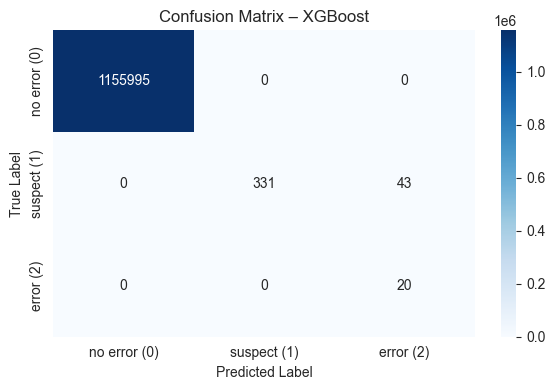

In [4]:
print("Classification Report:\n", classification_report(y_, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_, y_pred))
print("ROC-AUC:", roc_auc_score(y_, y_proba, multi_class="ovr"))
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix berechnen
cm = confusion_matrix(y_, y_pred)
labels = ['no error (0)', 'suspect (1)', 'error (2)']

# Als Heatmap plotten
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix – XGBoost')
plt.tight_layout()
plt.show()